# Project 2: effective interactions and induced three-body forces from full configuration interaction

Companion notebook to Appendix A, Project 2, of *Quantum mechanics for
many-particle systems*.  The code is the same as in
`BookManybody/BookPrograms/appendixA/effective3b.py`, which builds on the
bit-string machinery of the chapter-5 program `fci.py`; the notebook runs it
section by section and derives the formulas it implements.

Chapter 5 made two statements that sit uneasily together.  Full
configuration interaction is *exact*: in the basis of all Slater
determinants that a set of $n$ single-particle states allows, the
eigenvalue problem gives every eigenpair of $\hat H$, and every later
method is a truncation of it.  And the exponential wall, $\dim\mathcal H
=\binom{n}{N}$, puts that exact solution out of reach as soon as $n$ and $N$
are both moderately large.  The truncations of chapter 5 (CIS, CID, CISD)
cut the expansion by excitation level and keep the single-particle basis.
This project cuts the other way: we keep every excitation level -- we still
diagonalise -- but in a **model space** $P$ spanned by the determinants that
can be built from the $n_P<n$ lowest orbitals alone.  That is the shell model
of nuclear physics and the complete-active-space method of quantum chemistry,
and it raises the question every such calculation has to answer: which
interaction should be diagonalised in the small space?

The classical answer is an *effective interaction*, constructed in chapter 9
by perturbation theory.  Here we take the non-perturbative route, open
whenever the few-body problem can be solved exactly in the large space.
Given the exact eigenpairs, the Lee-Suzuki-Okubo similarity transformation
produces an effective Hamiltonian in $P$ that reproduces a chosen set of
exact eigenvalues.  Doing this for two particles gives an effective two-body
interaction $V^{(2)}_{\rm eff}$; doing it for three particles gives an
effective three-body Hamiltonian, and the part of it that is **not** the sum
of embedded one- and two-body operators is an induced effective three-body
interaction

$$
V^{(3)}_{\rm eff}=H^{(3)}_{\rm eff}-\sum_{i=1}^{3}t_i-\sum_{i<j}V^{(2)}_{\rm eff}(ij).
$$

This is the *a-body cluster* construction of the no-core shell model
(Navrátil, Vary and Barrett, Phys. Rev. Lett. **84**, 5728 (2000); Navrátil
and Ormand, Phys. Rev. C **68**, 034305 (2003)), and it is the same logic by
which the similarity renormalisation group generates induced three-body
forces.  We implement it on a toy model small enough that every step can be
checked by a full diagonalisation in the large space: spinless fermions in a
one-dimensional harmonic oscillator with a Gaussian interaction.

Contents:

1. The model space as a truncated FCI basis
2. The Lee-Suzuki-Okubo transformation: derivation
3. Cluster decomposition and induced many-body forces: derivation
4. The model
5. The effective two-body interaction ($a=2$)
6. The induced three-body interaction ($a=3$)
7. Four particles: does the hierarchy converge?
8. Dependence on the coupling strength
9. Dependence on the size of the model space
10. Intruder states and the choice of eigenvectors
11. Summary and tasks

## 1. The model space as a truncated FCI basis

The Hamiltonian is the usual one- plus two-body operator of chapter 3,

$$
\hat H=\sum_{pq}h_{pq}\,a^\dagger_p a_q+\frac14\sum_{pqrs}\langle pq|\hat v|rs\rangle_{\rm AS}\,a^\dagger_p a^\dagger_q a_s a_r ,
$$

in a single-particle basis of $n$ orbitals.  For $N$ particles the full
space is the FCI space of chapter 5: the $\binom{n}{N}$ determinants
$|p_1p_2\ldots p_N\rangle=a^\dagger_{p_1}\cdots a^\dagger_{p_N}|0\rangle$
with $p_1<\cdots<p_N$, each stored as a bit string exactly as in `fci.py`.
The **model space** is defined at the single-particle level: the $n_P<n$
lowest orbitals.  For $N$ particles the model space $P_N$ is spanned by all
$\binom{n_P}{N}$ determinants built from these orbitals alone, and its
complement $Q_N=1-P_N$ contains every determinant with at least one particle
in an excluded orbital.  The projectors $P$ and $Q$ are the many-dimensional
counterparts of the one-dimensional pair of chapter 9.

Note the difference from the truncations of chapter 5.  There CIS, CID and
CISD cut by excitation level with respect to a reference determinant and
kept the full single-particle basis.  Here the truncation is in the
*single-particle* basis and complete in excitation level: within $P_N$ every
$np$-$nh$ excitation of the lowest determinant is present, so the
model-space calculation is a full CI, only in a small space.  Defining $P$
through the orbitals, rather than through the total energy of the
determinants, is what makes the *product structure* $P_N\subset
P_{N-1}\otimes P_1$ hold, and we shall need that structure to embed a
two-body operator defined on $P_2$ into $P_3$ and $P_4$.

The goal is an effective Hamiltonian $H_{\rm eff}^{(N)}$ acting in $P_N$
whose eigenvalues are exact eigenvalues of $\hat H$, written as a sum of
one-, two- and three-body operators that we obtain from the one-, two- and
three-particle problems only.  If that works, we can attack an $N$-particle
system, for which the full space is out of reach, with the FCI machinery of
chapter 5 in the small space $P_N$, with

$$
H^{(N)}_{\rm eff}\approx\sum_i t_i+\sum_{i<j}V^{(2)}_{\rm eff}(ij)+\sum_{i<j<k}V^{(3)}_{\rm eff}(ijk).
$$

## 2. The Lee-Suzuki-Okubo transformation: derivation

### Decoupling by a similarity transformation

Let $P$ and $Q$ be the projectors on the model space and its complement in
the $N$-particle space, with $d_P=\dim P$.  We look for a similarity
transformation $\tilde H=e^{-\omega}\hat He^{\omega}$ such that $\tilde H$
does not connect $P$ to $Q$,

$$
Q\tilde HP=0 .
$$

The reader will recognise the structure of coupled-cluster theory (chapter
10): there the similarity transformation $e^{-\hat T}\hat He^{\hat T}$ is
required to have no matrix elements from the reference determinant to the
excited ones, and the amplitude equations are a decoupling condition of
exactly this type for a one-dimensional model space.

Following Lee and Suzuki we take $\omega$ to map $P$ into $Q$ and nothing
else, $\omega=Q\omega P$.  Then $\omega^2=Q\omega P\,Q\omega P=0$, so the
exponentials terminate: $e^{\omega}=1+\omega$ and $e^{-\omega}=1-\omega$, and

$$
\tilde H=(1-\omega)\hat H(1+\omega).
$$

Inserting this into the decoupling condition gives a quadratic (Riccati)
equation for $\omega$,

$$
Q\hat HP+Q\hat HQ\,\omega-\omega\,P\hat HP-\omega\,P\hat HQ\,\omega=0 ,
$$

which is what the iterative Lee-Suzuki schemes solve, and which reduces,
for a one-dimensional $P$, to the nonlinear equation for the correlation
coefficients that chapter 5 solves by iteration.  When the exact
eigenpairs are available there is a closed-form solution.  Pick $d_P$
eigenstates $\hat H|k\rangle=E_k|k\rangle$ whose projections $P|k\rangle$ are
linearly independent, and *define* $\omega$ by

$$
Q|k\rangle=\omega\,P|k\rangle\qquad\text{for each chosen }k .
$$

Since the $P|k\rangle$ span $P$ this fixes $\omega$ completely.  With this
choice $(1+\omega)P|k\rangle=P|k\rangle+Q|k\rangle=|k\rangle$, and therefore

$$
\tilde H\,P|k\rangle=(1-\omega)\hat H|k\rangle=E_k(1-\omega)(1+\omega)P|k\rangle=E_k\,P|k\rangle ,
$$

because $(1-\omega)(1+\omega)=1-\omega^2=1$.  The $d_P$ vectors
$P|k\rangle$ are eigenvectors of $\tilde H$ lying entirely in $P$, so
$Q\tilde HP=0$ and the model-space block

$$
H^{\rm LS}_{\rm eff}=P\tilde HP=P\hat HP+P\hat HQ\,\omega
$$

has *exactly* the chosen eigenvalues $E_k$.  This is the Lee-Suzuki
effective Hamiltonian.  It is not Hermitian: the $P|k\rangle$ are not
orthogonal even though the $|k\rangle$ are.

### Matrix form

Collect the chosen eigenvectors as the columns of an $n\times d_P$ matrix
$K$, and write $PK$ and $QK$ for its rows inside $P$ and $Q$.  The defining
relation reads $QK=\omega\,PK$, so

$$
\omega=(QK)(PK)^{-1},
$$

and the requirement that the $P|k\rangle$ be linearly independent is the
requirement that the $d_P\times d_P$ matrix $PK$ be invertible.  Its condition
number is the first thing to look at when the construction misbehaves
(Section 10).

### The Hermitian (Okubo) form

The map $X=(P+\omega)$ sends $P|k\rangle$ to $|k\rangle$, i.e. it maps the
model space one-to-one onto the subspace spanned by the chosen exact
eigenstates.  It is not unitary; its metric is

$$
S=X^\dagger X=P+\omega^\dagger\omega .
$$

The operator $U=XS^{-1/2}$ *is* an isometry from $P$ onto that subspace
($U^\dagger U=S^{-1/2}X^\dagger XS^{-1/2}=P$), so the Hamiltonian restricted
to the chosen eigenstates and expressed in an orthonormal basis of $P$ is

$$
H_{\rm eff}=U^\dagger\hat HU=(P+\omega^\dagger\omega)^{-1/2}(P+\omega^\dagger)\hat H(P+\omega)(P+\omega^\dagger\omega)^{-1/2}.
$$

This is Okubo's Hermitian effective Hamiltonian.  It is unitarily equivalent
to $\hat H$ on the chosen subspace, so it has exactly the eigenvalues $E_k$,
and it is what we shall use.  A compact formula follows from
$X\,PK=K$, i.e. $X=K(PK)^{-1}$ on $P$:

$$
S=(PK)^{-\dagger}(PK)^{-1},\qquad
H_{\rm eff}=S^{-1/2}(PK)^{-\dagger}\,{\rm diag}(E_k)\,(PK)^{-1}S^{-1/2}.
$$

The class `LeeSuzuki` evaluates precisely this, sector by sector for each
conserved quantum number, and also returns the non-Hermitian form for
comparison.

### What is not fixed by the construction

Two choices have been made.  First, which $d_P$ eigenstates to reproduce: the
lowest ones in each symmetry sector is the natural choice when the model
space is well separated in energy from its complement, but in general the
$d_P$ states with the largest norm inside $P$ are the safer choice
(Section 10).  Second, the Hermitisation: any unitary on $P$ gives another
equally valid $H_{\rm eff}$.  An effective interaction is therefore never
unique; what is fixed is the spectrum it reproduces.  The Bloch-Horowitz
energy-dependent effective Hamiltonian
$H_{\rm eff}(E)=P\hat HP+P\hat HQ(E-Q\hat HQ)^{-1}Q\hat HP$ reproduces the
same eigenvalues when $E$ is set self-consistently to each $E_k$ -- it is
the Brillouin-Wigner form of chapter 9 for a degenerate model space; the
Lee-Suzuki construction is the energy-independent (folded-diagram) version.

## 3. Cluster decomposition and induced many-body forces: derivation

### A $k$-body operator is fixed by its $k$-particle matrix elements

A $k$-body operator is, in second quantisation,

$$
\hat O=\frac{1}{(k!)^2}\sum_{s_1\ldots s_k}\sum_{p_1\ldots p_k}
\langle s_1\ldots s_k|\hat O|p_1\ldots p_k\rangle_{\rm AS}\;
a^\dagger_{s_1}\cdots a^\dagger_{s_k}a_{p_k}\cdots a_{p_1}.
$$

The antisymmetry of the matrix elements lets us restrict both sums to ordered
tuples $S=(s_1<\cdots<s_k)$ and $P=(p_1<\cdots<p_k)$, absorbing the
$(k!)^2$:

$$
\hat O=\sum_{S,P}\langle S|\hat O|P\rangle\;a^\dagger_S\,a_P,\qquad
a^\dagger_S=a^\dagger_{s_1}\cdots a^\dagger_{s_k},\quad a_P=a_{p_k}\cdots a_{p_1},
$$

where $|P\rangle=a^\dagger_P|0\rangle$ is a $k$-particle Slater determinant.
On the $k$-particle space $a^\dagger_Sa_P|P'\rangle=\delta_{PP'}|S\rangle$,
so the right-hand side reproduces the matrix of $\hat O$ between
$k$-particle determinants, and since a normal-ordered $k$-body operator is
uniquely determined by these matrix elements, the identity holds on the
whole Fock space.  In particular it tells us how to **embed** a $k$-body
operator in the $N$-particle space: for $N$-particle determinants
$|D\rangle$ and $|D'\rangle$,

$$
\langle D'|\hat O|D\rangle=\sum_{P\subset D}\;\sum_{S}\langle S|\hat O|P\rangle\,
\langle D'|a^\dagger_Sa_P|D\rangle ,
$$

where the sum runs over the $k$-subsets $P$ of the occupied orbitals of $D$,
and $\langle D'|a^\dagger_Sa_P|D\rangle$ is $\pm1$ if removing $P$ from $D$
and adding $S$ gives $D'$, and zero otherwise.  The sign is the fermionic phase of the bit-string representation, and the
whole formula is exactly what `KBodyOperator.embed` computes with the
`annihilate` and `create` routines of `fci.py`, for any $k$.  The
Condon-Slater rules of chapter 3 are the special cases $k=1$ and $k=2$:
the one-body Hamiltonian is $k=1$ with matrix $h_{pq}$, the bare
interaction is $k=2$ with $\langle rs|\hat v|pq\rangle_{\rm AS}$, and the
band structure of the FCI matrix in chapter 5 is the statement that the
formula vanishes when $D$ and $D'$ differ by more than $k$ orbitals.  The
effective three-body interaction we are after will be a $k=3$ operator
given by its matrix in the three-particle model space $P_3$, and exercise
2 of chapter 5 has already told us what it does to the band structure.

### The $a$-body cluster hierarchy

Solve the $a$-particle problem exactly and construct
$H^{(a)}_{\rm eff}$ in $P_a$ for $a=1,2,3,\ldots$  Each $H^{(a)}_{\rm eff}$ is a
matrix on the $a$-particle model space, hence, by the identity above, an
$a$-body operator.  Define recursively

$$
\begin{aligned}
V^{(1)}_{\rm eff}&=H^{(1)}_{\rm eff},\\
V^{(2)}_{\rm eff}&=H^{(2)}_{\rm eff}-\sum_{i=1}^{2}V^{(1)}_{\rm eff}(i),\\
V^{(3)}_{\rm eff}&=H^{(3)}_{\rm eff}-\sum_{i=1}^{3}V^{(1)}_{\rm eff}(i)-\sum_{i<j}V^{(2)}_{\rm eff}(ij),
\end{aligned}
$$

and so on, where every operator on the right is embedded into the
$a$-particle model space with the recipe above.  By construction the
$a$-particle effective Hamiltonian truncated at cluster level $a$ is exact,
and for $N>a$ particles

$$
H^{(N)}_{\rm eff}=\sum_{i}V^{(1)}_{\rm eff}(i)+\sum_{i<j}V^{(2)}_{\rm eff}(ij)+\sum_{i<j<k}V^{(3)}_{\rm eff}(ijk)+\cdots
$$

is the *a-body cluster approximation* when the series is stopped after
$a$-body terms.  Here $V^{(1)}_{\rm eff}$ is trivial: the one-body
Hamiltonian is diagonal in the oscillator basis, so the one-particle model
space is already exact and $V^{(1)}_{\rm eff}=t$.  In the presence of a
one-body field with off-diagonal elements between $P$ and $Q$ this step would
be non-trivial too.

Why the hierarchy rather than the $N$-body problem itself?  Because the
decomposition of an $N$-body operator into one-, two- and three-body pieces
is *not* unique when we only know its matrix elements in the $N$-particle
sector: an $N$-body effective Hamiltonian has $d_{P_N}^2$ matrix elements,
far more than a $1+2+3$-body operator has, so the inverse problem is
overdetermined and any solution is a fit.  The $a$-particle sectors, in
contrast, determine the $a$-body operators uniquely, and a particle-number
conserving unitary transformation of $\hat H$ on Fock space has a well-defined
cluster decomposition obtained sector by sector in exactly this way.

### Why an induced three-body force appears at all

The bare Hamiltonian has no three-body term.  The induced term arises because
the decoupling transformation acts on the three-particle system as a whole.
Perturbatively, in second order the model-space Hamiltonian is
$P\hat HP+P\hat V Q(E_0-\hat H_0)^{-1}Q\hat VP$.  Among the terms in the
three-particle space are *connected* ones in which particle 1 is excited
into $Q$ by interacting with particle 2 and brought back by interacting with
particle 3.  No two-body operator embedded with a spectator can produce such
a term; it is a genuine three-body operator of order $v^2$.  We shall see the
quadratic scaling in Section 8.  The Lee-Suzuki $\omega$ resums these
diagrams to all orders, together with the folded diagrams that remove the
energy dependence.

The same mechanism produces the induced three-body forces of the similarity
renormalisation group, where the unitary transformation is generated by a
flow equation instead of being read off from eigenvectors, and it is the
reason why the no-core shell model needs at least the three-body cluster
approximation when the bare interaction is softened.  Conversely, once
$V^{(3)}_{\rm eff}$ is known, normal ordering with respect to a reference
determinant turns most of it into zero-, one- and two-body pieces
(chapter 3), which is how three-body forces enter mean-field, coupled-cluster
and in-medium SRG calculations at two-body cost -- the procedure anticipated
in the answer to exercise 2 of chapter 5.

## 4. The model

We take spinless fermions in a one-dimensional harmonic oscillator
($\hbar=m=\omega=1$) with the Gaussian interaction

$$
v(x-y)=V_0\,e^{-(x-y)^2/2\sigma^2}.
$$

The single-particle basis consists of the $n=14$ lowest oscillator functions
$\varphi_0,\ldots,\varphi_{13}$ and the model space of the $n_P=6$ lowest.
The two-body matrix elements
$\langle pq|v|rs\rangle=\int dx\,dy\,\varphi_p(x)\varphi_q(y)v(x-y)\varphi_r(x)\varphi_s(y)$
are computed on a grid; parity is the only conserved quantum number of a
determinant and the Lee-Suzuki construction is carried out separately in the
even and odd sectors.

One modification of the pure oscillator is essential.  The single-particle
energies are $\epsilon_n=n+\tfrac12$, so the three-particle determinant
$|345\rangle$ of the model space, with $13.5$ units of energy, is degenerate
with the excluded determinants $|0\,1\,12\rangle$, $|0\,2\,11\rangle$,
$|1\,2\,10\rangle$, and so on: for an orbital truncation of the oscillator
the top of $P$ overlaps in energy with the bottom of $Q$ as soon as
$N\ge2$.  These *intruder states* make the effective interaction
ill-defined in the limit of weak coupling (the exact eigenstates are then
arbitrary mixtures of degenerate $P$ and $Q$ determinants) and are the
classic obstacle to effective-interaction theory, analysed by Schucan and
Weidenmüller in 1972.  The no-core shell model avoids them by truncating on
the total number of oscillator quanta rather than orbital by orbital.  We
keep the orbital truncation, because it gives the product structure of
Section 1, and instead open a **shell gap**: the excluded orbitals are shifted
up by $\Delta$,

$$
\epsilon_n=n+\tfrac12+\Delta\,\theta(n-n_P).
$$

With $\Delta=3$ the model space is well separated for $N\le4$.  Section 10
turns $\Delta$ back down and shows the intruders arrive.

The bootstrap cell below puts every `BookPrograms/chapter*` and
`BookPrograms/appendix*` directory on the path, because `effective3b.py`
imports the bit-string routines of the chapter-5 program `fci.py`.

In [1]:
import sys, os, glob
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import eigh

# the chapter programs live in BookPrograms/chapterNN and the appendix
# programs in BookPrograms/appendixX; put them all on the path
for _pattern in ("chapter*", "appendix*"):
    for _d in sorted(glob.glob(os.path.join("..", "BookManybody",
                                            "BookPrograms", _pattern))):
        if _d not in sys.path:
            sys.path.insert(0, _d)
import effective3b as e3

np.set_printoptions(precision=6, suppress=True, linewidth=120)

In [2]:
n, n_P = 14, 6              # single-particle orbitals: full space and model space
V0, sigma = -2.0, 1.0       # Gaussian interaction
gap = 3.0                   # shell gap between model space and excluded space

ho = e3.HarmonicOscillator1D(n)
h = ho.one_body(gap=gap, n_P=n_P)
v = ho.two_body(e3.gaussian(V0, sigma))

print("single-particle energies:", np.diag(h))
print("a few antisymmetrised matrix elements <pq|v|rs>_AS:")
for (p, q, r, s) in [(0, 1, 0, 1), (0, 1, 2, 3), (0, 2, 1, 3), (2, 3, 4, 5)]:
    print(f"  <{p}{q}|v|{r}{s}> = {v[p, q, r, s]: .6f}")

single-particle energies: [ 0.5  1.5  2.5  3.5  4.5  5.5  9.5 10.5 11.5 12.5 13.5 14.5 15.5 16.5]
a few antisymmetrised matrix elements <pq|v|rs>_AS:
  <01|v|01> = -0.707107
  <01|v|23> = -0.191366
  <02|v|13> = -0.306186
  <23|v|45> = -0.213745


The bare Hamiltonian is assembled from the one- and two-body operators by the
embedding routine of Section 3.  As a check on the machinery we compare the
diagonal matrix element of a determinant with the Condon-Slater rule of chapter 3
$\langle D|\hat H|D\rangle=\sum_{p\in D}h_{pp}+\sum_{p<q\in D}\langle pq|v|pq\rangle_{\rm AS}$
and confirm that the matrix is symmetric.

In [3]:
h1 = e3.KBodyOperator.from_one_body(h)
v2 = e3.KBodyOperator.from_two_body(v)
B3 = e3.DeterminantBasis(range(n), 3)
H3 = h1.embed(B3) + v2.embed(B3)

D = (0, 3, 7)
i = B3.index[D]
slater_condon = sum(h[p, p] for p in D) + sum(v[p, q, p, q] for p in D for q in D if p < q)
print(f"{len(B3)} three-particle determinants")
print(f"<{D}|H|{D}>: embedding {H3[i, i]:.10f}, Slater-Condon {slater_condon:.10f}")
print("symmetric:", np.allclose(H3, H3.T))

364 three-particle determinants
<(0, 3, 7)|H|(0, 3, 7)>: embedding 12.9655337238, Slater-Condon 12.9655337238
symmetric: True


## 5. The effective two-body interaction ($a=2$)

The class `ClusterHierarchy` runs the whole construction: it builds the
exact two- and three-particle Hamiltonians, applies the Lee-Suzuki-Okubo
transformation in each parity sector, and subtracts the embedded lower
clusters.  We first look at the two-particle step.

In [4]:
ch = e3.ClusterHierarchy(h, v, n_P, orbital_parity=ho.parity(), select="overlap")

ls2 = ch.ls[2]
B2, B2P = ch.basis(2), ch.basis(2, model=True)
print(f"two-particle space: {len(B2)} determinants, model space: {len(B2P)}")
print("condition number of PK in each parity sector:", ls2.condition_numbers)
print("norm of omega in each sector:                ", ls2.omega_norm)
print(f"max |eig(H_eff) - E_k| = {ls2.check():.2e}")
print("H_eff Hermitian:", np.allclose(ls2.H_eff, ls2.H_eff.T))
print("non-Hermitian Lee-Suzuki form has the same spectrum:",
      np.allclose(np.sort(np.linalg.eigvals(ls2.H_eff_nonhermitian).real),
                  ls2.chosen_energies))

two-particle space: 91 determinants, model space: 15
condition number of PK in each parity sector: {-1: 1.0066742242017943, 1: 1.0064412828084044}
norm of omega in each sector:                 {-1: 0.18102973095030403, 1: 0.17551150391063217}
max |eig(H_eff) - E_k| = 7.11e-15
H_eff Hermitian: True
non-Hermitian Lee-Suzuki form has the same spectrum: True


The effective two-body interaction $V^{(2)}_{\rm eff}=H^{(2)}_{\rm eff}-t_1-t_2$
differs from the bare interaction restricted to $P$ by the renormalisation
that virtual excitations into $Q$ produce.  The two lowest exact
two-particle energies are reproduced by $t+V^{(2)}_{\rm eff}$ in $P_2$ exactly,
while $P\hat HP$ with the bare interaction misses them.

lowest two-particle energies
  exact      : [1.184833 2.187946 3.19293  3.574968 4.222133]
  bare in P  : [1.18655  2.194871 3.20631  3.580234 4.253854]
  V2_eff in P: [1.184833 2.187946 3.19293  3.574968 4.222133]

||V2_bare|| = 2.7350, ||V2_eff|| = 2.8199, ||V2_eff - V2_bare|| = 0.1198


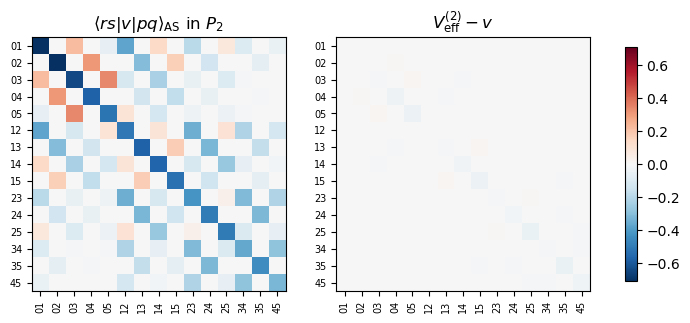

In [5]:
T2 = ch.h_P.embed(B2P)
E_exact = eigh(ch.bare_hamiltonian(2), eigvals_only=True)[:len(B2P)]
E_bare  = eigh(T2 + ch.V2_bare.embed(B2P), eigvals_only=True)
E_eff   = eigh(T2 + ch.V2_eff.embed(B2P), eigvals_only=True)
print("lowest two-particle energies")
print("  exact      :", E_exact[:5])
print("  bare in P  :", E_bare[:5])
print("  V2_eff in P:", E_eff[:5])
print(f"\n||V2_bare|| = {ch.V2_bare.norm():.4f}, ||V2_eff|| = {ch.V2_eff.norm():.4f}, "
      f"||V2_eff - V2_bare|| = {(ch.V2_eff - ch.V2_bare).norm():.4f}")

fig, ax = plt.subplots(1, 2, figsize=(9, 3.8))
vmax = np.max(np.abs(ch.V2_eff.matrix))
labels = ["".join(map(str, d)) for d in B2P.dets]
for a, (M, title) in zip(ax, [(ch.V2_bare.matrix, r"$\langle rs|v|pq\rangle_{\rm AS}$ in $P_2$"),
                              ((ch.V2_eff - ch.V2_bare).matrix, r"$V^{(2)}_{\rm eff}-v$")]):
    im = a.imshow(M, cmap="RdBu_r", vmin=-vmax, vmax=vmax)
    a.set_title(title)
    a.set_xticks(range(len(labels))); a.set_xticklabels(labels, rotation=90, fontsize=7)
    a.set_yticks(range(len(labels))); a.set_yticklabels(labels, fontsize=7)
fig.colorbar(im, ax=ax, shrink=0.8)
plt.show()

## 6. The induced three-body interaction ($a=3$)

Now the three-particle problem.  $H^{(3)}_{\rm eff}$ is a $20\times20$ matrix
in $P_3$ that reproduces twenty exact three-particle energies.  Subtracting
the embedded one-body part and the embedded $V^{(2)}_{\rm eff}$ leaves the
induced three-body interaction $V^{(3)}_{\rm eff}$, again a $20\times20$
matrix, which by Section 3 defines a three-body operator on Fock space.

In [6]:
ls3 = ch.ls[3]
B3P = ch.basis(3, model=True)
print(f"three-particle space: {len(ch.basis(3))} determinants, model space: {len(B3P)}")
print("condition number of PK in each parity sector:", ls3.condition_numbers)
print(f"max |eig(H_eff) - E_k| = {ls3.check():.2e}")

spectra3 = ch.model_space_spectra(3, n_states=6)
print("\nlowest three-particle energies")
for label, E in spectra3.items():
    print(f"  {label:22s}", E)

three-particle space: 364 determinants, model space: 20
condition number of PK in each parity sector: {-1: 1.017576367846106, 1: 1.0219656153225432}
max |eig(H_eff) - E_k| = 2.13e-14

lowest three-particle energies
  exact                  [2.310362 3.324123 4.392015 4.728877 5.394779 5.785757]
  bare (PHP)             [2.325412 3.357059 4.462551 4.78783  5.469447 5.865945]
  h + V2_eff             [2.307649 3.318338 4.407699 4.745798 5.395576 5.816277]
  h + V2_eff + V3_eff    [2.310362 3.324123 4.392015 4.728877 5.394779 5.785757]


With $t+V^{(2)}_{\rm eff}$ alone the three-particle energies are already much
better than with the bare interaction, but they are not exact: the residual
is what $V^{(3)}_{\rm eff}$ repairs, by construction exactly.  Its size can be
gauged in three ways: the Frobenius norm of its matrix, its largest matrix
element, and its expectation value in the exact ground state.

||V2_eff|| = 2.8199,  ||V3_eff|| = 0.1843,  ratio 0.065
largest |<S|V3_eff|P>| = 0.0367, largest |<rs|V2_eff|pq>| = 0.7102
Hermitian: True
<gs|V3_eff|gs> =  0.00263  (E_gs = 2.31036)


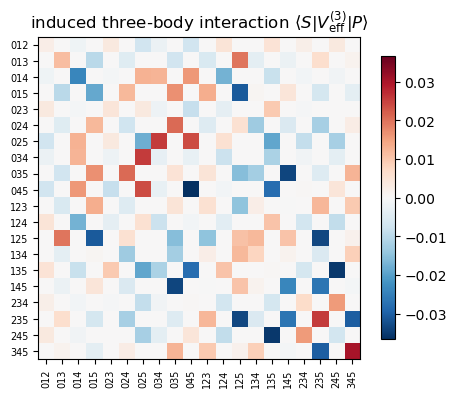

In [7]:
V3 = ch.V3_eff
print(f"||V2_eff|| = {ch.V2_eff.norm():.4f},  ||V3_eff|| = {V3.norm():.4f},  "
      f"ratio {V3.norm() / ch.V2_eff.norm():.3f}")
print(f"largest |<S|V3_eff|P>| = {np.max(np.abs(V3.matrix)):.4f}, "
      f"largest |<rs|V2_eff|pq>| = {np.max(np.abs(ch.V2_eff.matrix)):.4f}")
print("Hermitian:", np.allclose(V3.matrix, V3.matrix.T))

# ground-state expectation value of V3_eff in the model space
T3 = ch.h_P.embed(B3P)
E, C = eigh(T3 + ch.V2_eff.embed(B3P) + V3.embed(B3P))
gs = C[:, 0]
print(f"<gs|V3_eff|gs> = {gs @ V3.matrix @ gs: .5f}  (E_gs = {E[0]:.5f})")

labels3 = ["".join(map(str, d)) for d in B3P.dets]
fig, ax = plt.subplots(figsize=(5.2, 4.6))
vmax = np.max(np.abs(V3.matrix))
im = ax.imshow(V3.matrix, cmap="RdBu_r", vmin=-vmax, vmax=vmax)
ax.set_xticks(range(len(labels3))); ax.set_xticklabels(labels3, rotation=90, fontsize=7)
ax.set_yticks(range(len(labels3))); ax.set_yticklabels(labels3, fontsize=7)
ax.set_title(r"induced three-body interaction $\langle S|V^{(3)}_{\rm eff}|P\rangle$")
fig.colorbar(im, ax=ax, shrink=0.8)
plt.show()

The block structure is parity: even and odd three-particle determinants do
not mix.  The largest elements involve the highest model-space orbitals,
which are closest to the excluded space and feel the decoupling most.

## 7. Four particles: does the hierarchy converge?

The real test is a system we did not use to build the interactions.  For
four particles the full space has $\binom{14}{4}=1001$ determinants and the
model space $\binom{6}{4}=15$.  We compare the exact spectrum with the
model-space spectra obtained with the bare interaction, with
$t+V^{(2)}_{\rm eff}$, and with $t+V^{(2)}_{\rm eff}+V^{(3)}_{\rm eff}$.  The
remaining discrepancy is the induced four-body interaction, which we can
also extract by carrying the hierarchy one step further.

In [8]:
spectra4 = ch.model_space_spectra(4, n_states=6)
print("lowest four-particle energies")
for label, E in spectra4.items():
    print(f"  {label:22s}", E)
print("\nerrors in the ground-state energy:")
for label, E in spectra4.items():
    if label != "exact":
        print(f"  {label:22s} {E[0] - spectra4['exact'][0]: .2e}")

lowest four-particle energies
  exact                  [4.016621 5.138837 6.133578 6.533993 7.292868 7.719233]
  bare (PHP)             [4.072766 5.266284 6.260734 6.704104 7.466165 7.82506 ]
  h + V2_eff             [3.998842 5.167793 6.127434 6.608091 7.326293 7.712288]
  h + V2_eff + V3_eff    [4.016232 5.137136 6.13501  6.534664 7.288118 7.723718]

errors in the ground-state energy:
  bare (PHP)              5.61e-02
  h + V2_eff             -1.78e-02
  h + V2_eff + V3_eff    -3.89e-04


In [9]:
V4 = ch.add_four_body()
print(f"||V2_eff|| = {ch.V2_eff.norm():.4f}  ||V3_eff|| = {ch.V3_eff.norm():.4f}  "
      f"||V4_eff|| = {V4.norm():.4f}")
print(f"largest elements: {np.max(np.abs(ch.V2_eff.matrix)):.4f}  "
      f"{np.max(np.abs(ch.V3_eff.matrix)):.4f}  {np.max(np.abs(V4.matrix)):.4f}")
E4 = ch.model_space_spectra(4, n_states=4)["h + V2_eff + V3_eff + V4_eff"]
print("with V4_eff the four-particle spectrum is exact:",
      np.allclose(E4, spectra4["exact"][:4]))

||V2_eff|| = 2.8199  ||V3_eff|| = 0.1843  ||V4_eff|| = 0.1009
largest elements: 0.7102  0.0367  0.0348


with V4_eff the four-particle spectrum is exact: True


The hierarchy converges.  The renormalisation of the two-body interaction is
an order of magnitude larger than the induced three-body term, and the induced
four-body term is smaller still, though by a smaller factor.  In the energies
the effect is clearer: the two-body cluster approximation leaves an error of
about $2\times10^{-2}$ in the four-particle ground state, the three-body
cluster approximation reduces it to $4\times10^{-4}$, one part in $10^4$ of
the interaction energy, and the four-body term makes the spectrum exact by
construction.  This is the pattern one hopes for, and, for realistic nuclear
interactions, the pattern the no-core shell model relies on.

## 8. Dependence on the coupling strength

Section 3 argued that the induced three-body force is a second-order effect
in the interaction.  We scan $V_0$ and plot the norms of
$V^{(2)}_{\rm eff}-v$ and of $V^{(3)}_{\rm eff}$; both should scale as $V_0^2$
for weak coupling, where the perturbative picture applies, and depart from it
when the coupling becomes strong.

V0 = -0.0625: ||V2_eff - v|| = 1.139e-04  ||V3_eff|| = 1.647e-04  N=4 error with V2: 2.01e-05, with V2+V3: 2.58e-08


V0 = -0.1250: ||V2_eff - v|| = 4.561e-04  ||V3_eff|| = 6.599e-04  N=4 error with V2: 8.14e-05, with V2+V3: 2.00e-07


V0 = -0.2500: ||V2_eff - v|| = 1.827e-03  ||V3_eff|| = 2.650e-03  N=4 error with V2: 3.31e-04, with V2+V3: 1.48e-06


V0 = -0.5000: ||V2_eff - v|| = 7.330e-03  ||V3_eff|| = 1.069e-02  N=4 error with V2: 1.35e-03, with V2+V3: 9.73e-06


V0 = -1.0000: ||V2_eff - v|| = 2.951e-02  ||V3_eff|| = 4.350e-02  N=4 error with V2: 5.39e-03, with V2+V3: 3.65e-05


V0 = -2.0000: ||V2_eff - v|| = 1.198e-01  ||V3_eff|| = 1.843e-01  N=4 error with V2: 1.78e-02, with V2+V3: 3.89e-04


V0 = -4.0000: ||V2_eff - v|| = 4.984e-01  ||V3_eff|| = 8.213e-01  N=4 error with V2: 2.03e-02, with V2+V3: 2.16e-02
V0 = -8.0000: ||V2_eff - v|| = 2.235e+00  ||V3_eff|| = 1.079e+01  N=4 error with V2: 1.29e-01, with V2+V3: 3.06e-01


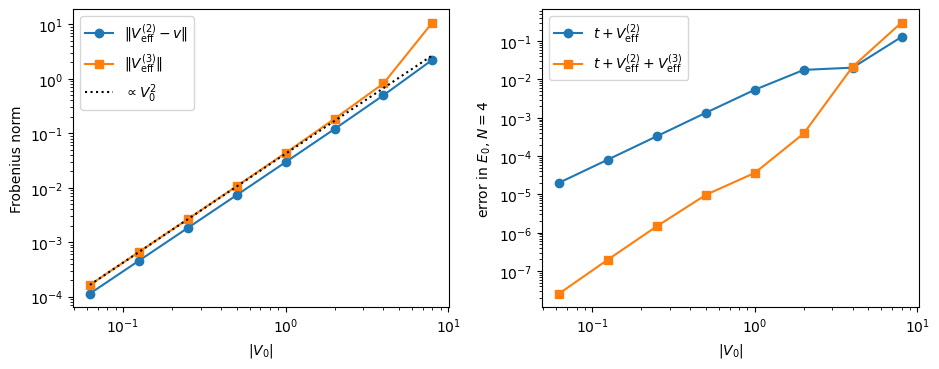

In [10]:
couplings = np.array([0.0625, 0.125, 0.25, 0.5, 1.0, 2.0, 4.0, 8.0])
dV2, V3n, V4n, err3, err4 = [], [], [], [], []
for c in couplings:
    chc = e3.ClusterHierarchy(h, ho.two_body(e3.gaussian(-c, sigma)), n_P,
                              orbital_parity=ho.parity(), select="overlap")
    dV2.append((chc.V2_eff - chc.V2_bare).norm())
    V3n.append(chc.V3_eff.norm())
    s4 = chc.model_space_spectra(4, n_states=1)
    err3.append(abs(s4["h + V2_eff"][0] - s4["exact"][0]))
    err4.append(abs(s4["h + V2_eff + V3_eff"][0] - s4["exact"][0]))
    print(f"V0 = {-c:7.4f}: ||V2_eff - v|| = {dV2[-1]:.3e}  ||V3_eff|| = {V3n[-1]:.3e}  "
          f"N=4 error with V2: {err3[-1]:.2e}, with V2+V3: {err4[-1]:.2e}")

fig, ax = plt.subplots(1, 2, figsize=(9.5, 3.8))
ax[0].loglog(couplings, dV2, "o-", label=r"$\|V^{(2)}_{\rm eff}-v\|$")
ax[0].loglog(couplings, V3n, "s-", label=r"$\|V^{(3)}_{\rm eff}\|$")
ax[0].loglog(couplings, V3n[0] * (couplings / couplings[0]) ** 2, "k:", label=r"$\propto V_0^2$")
ax[0].set_xlabel(r"$|V_0|$"); ax[0].set_ylabel("Frobenius norm"); ax[0].legend()
ax[1].loglog(couplings, err3, "o-", label=r"$t+V^{(2)}_{\rm eff}$")
ax[1].loglog(couplings, err4, "s-", label=r"$t+V^{(2)}_{\rm eff}+V^{(3)}_{\rm eff}$")
ax[1].set_xlabel(r"$|V_0|$"); ax[1].set_ylabel(r"error in $E_0$, $N=4$"); ax[1].legend()
plt.tight_layout(); plt.show()

At weak coupling both curves follow the $V_0^2$ line, confirming the
diagrammatic argument, and the three-body cluster approximation improves the
four-particle ground state by two to three orders of magnitude.  As the
coupling grows the induced three-body term becomes larger than the
renormalisation of the two-body term itself, and the induced four-body term,
visible as the error that remains after including $V^{(3)}_{\rm eff}$, grows
faster still: at $V_0=-4$ adding $V^{(3)}_{\rm eff}$ no longer improves the
four-particle ground state and at $V_0=-8$ it makes it worse.  The cluster
expansion converges more slowly the harder the interaction, which is the
reason for softening realistic interactions before they are used in a small
space.

## 9. Dependence on the size of the model space

Enlarging the model space (keeping the gap $\Delta$ above its top) should make
the effective interactions approach the bare ones and the induced three-body
term vanish.  When $n_P=n$ there is nothing to decouple, $\omega=0$, and
$V^{(3)}_{\rm eff}$ must be zero to machine precision.  Because the number of
three-body matrix elements grows with $n_P$, the Frobenius norm is not the
right measure across model spaces; we monitor the largest matrix element and
the error of the three-particle ground state obtained with
$t+V^{(2)}_{\rm eff}$ alone, which is the energy shift $V^{(3)}_{\rm eff}$ has
to supply.

n_P =  3: dim P_3 =    1  max|V2_eff - v| = 4.88e-02  max|V3_eff| = 1.45e-03  E_0(N=3) error with V2_eff only = 1.45e-03
n_P =  4: dim P_3 =    4  max|V2_eff - v| = 5.01e-02  max|V3_eff| = 4.09e-02  E_0(N=3) error with V2_eff only = 1.46e-04
n_P =  5: dim P_3 =   10  max|V2_eff - v| = 4.75e-02  max|V3_eff| = 4.05e-02  E_0(N=3) error with V2_eff only = 5.53e-03
n_P =  6: dim P_3 =   20  max|V2_eff - v| = 4.64e-02  max|V3_eff| = 3.67e-02  E_0(N=3) error with V2_eff only = 2.71e-03


n_P =  7: dim P_3 =   35  max|V2_eff - v| = 4.47e-02  max|V3_eff| = 5.08e-02  E_0(N=3) error with V2_eff only = 2.07e-03
n_P =  8: dim P_3 =   56  max|V2_eff - v| = 4.25e-02  max|V3_eff| = 5.69e-02  E_0(N=3) error with V2_eff only = 9.65e-04


n_P = 10: dim P_3 =  120  max|V2_eff - v| = 3.67e-02  max|V3_eff| = 5.13e-02  E_0(N=3) error with V2_eff only = 2.33e-04


n_P = 12: dim P_3 =  220  max|V2_eff - v| = 2.72e-02  max|V3_eff| = 2.63e-02  E_0(N=3) error with V2_eff only = 4.24e-05


n_P = 14: dim P_3 =  364  max|V2_eff - v| = 8.23e-13  max|V3_eff| = 3.26e-12  E_0(N=3) error with V2_eff only = 2.18e-14


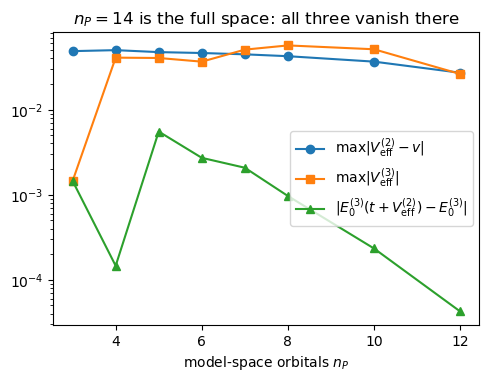

In [11]:
sizes = [3, 4, 5, 6, 7, 8, 10, 12, 14]
v_default = ho.two_body(e3.gaussian(V0, sigma))
maxV3, shift3, maxdV2 = [], [], []
for nP in sizes:
    hP = ho.one_body(gap=gap, n_P=nP)
    chP = e3.ClusterHierarchy(hP, v_default, nP, orbital_parity=ho.parity(), select="overlap")
    s3 = chP.model_space_spectra(3, n_states=1)
    maxV3.append(np.max(np.abs(chP.V3_eff.matrix)))
    maxdV2.append(np.max(np.abs((chP.V2_eff - chP.V2_bare).matrix)))
    shift3.append(abs(s3["h + V2_eff"][0] - s3["exact"][0]))
    print(f"n_P = {nP:2d}: dim P_3 = {len(chP.basis(3, model=True)):4d}  "
          f"max|V2_eff - v| = {maxdV2[-1]:.2e}  max|V3_eff| = {maxV3[-1]:.2e}  "
          f"E_0(N=3) error with V2_eff only = {shift3[-1]:.2e}")

fig, ax = plt.subplots(figsize=(5.5, 3.8))
ax.semilogy(sizes[:-1], maxdV2[:-1], "o-", label=r"$\max|V^{(2)}_{\rm eff}-v|$")
ax.semilogy(sizes[:-1], maxV3[:-1], "s-", label=r"$\max|V^{(3)}_{\rm eff}|$")
ax.semilogy(sizes[:-1], shift3[:-1], "^-", label=r"$|E_0^{(3)}(t+V^{(2)}_{\rm eff})-E_0^{(3)}|$")
ax.set_xlabel(r"model-space orbitals $n_P$"); ax.legend()
ax.set_title(r"$n_P=14$ is the full space: all three vanish there")
plt.show()

The largest matrix elements of $V^{(2)}_{\rm eff}-v$ and of $V^{(3)}_{\rm eff}$
hardly decrease with $n_P$: they always involve the highest model-space
orbitals, which sit right below the gap whatever $n_P$ is, and the gap itself
is kept fixed.  What does decrease, by almost two orders of magnitude from
$n_P=5$ to $n_P=12$, is the effect of $V^{(3)}_{\rm eff}$ on the ground state,
because the orbitals where it is large move further and further away from
the configurations that dominate the low-lying states.  This is the way
effective many-body forces disappear when the model space is enlarged: not
element by element, but by becoming irrelevant for the states one cares
about.  In the full space, $n_P=14$, all three quantities are zero to
machine precision, which is a stringent test of the whole embedding and
subtraction machinery.

## 10. Intruder states and the choice of eigenvectors

Finally we close the shell gap.  As $\Delta\to0$ excluded determinants
descend into the energy range of the model space.  If we insist on
reproducing the *lowest* $d_P$ eigenvalues in each sector, some of the chosen
eigenstates are intruders that live mostly in $Q$; their projections on $P$
are nearly linearly dependent, the condition number of $PK$ explodes, and
the effective interaction acquires huge, strongly state-dependent pieces
that spoil the cluster hierarchy.  Choosing instead the $d_P$ eigenstates
with the largest norm in $P$ keeps $PK$ well conditioned for moderate gaps,
but when the gap vanishes even that fails: the exact states are then
genuine $P$-$Q$ mixtures and no choice of $d_P$ of them spans the model
space gracefully.  We monitor the condition number, the size of
$V^{(3)}_{\rm eff}$, and the error of the four-particle ground state with
$t+V^{(2)}_{\rm eff}+V^{(3)}_{\rm eff}$.

  gap |  cond(PK), lowest   ||V3||   N=4 err |  cond(PK), overlap   ||V3||   N=4 err
 0.00 |            8745.6    4.943  6.77e-02 |             4202.3    6.842  4.38e-01
 0.35 |            6931.6    4.313  1.74e-03 |             4504.2    4.693  2.04e-02
 0.70 |            5788.1    4.066  4.40e-02 |                1.5    0.547  3.35e-03
 1.50 |            4314.8    3.787  3.00e-02 |                1.0    0.284  7.51e-04
 3.00 |            1521.1    2.883  5.60e-03 |                1.0    0.184  3.89e-04
 6.00 |               1.0    0.109  2.57e-04 |                1.0    0.109  2.57e-04
12.00 |               1.0    0.062  1.01e-04 |                1.0    0.062  1.01e-04


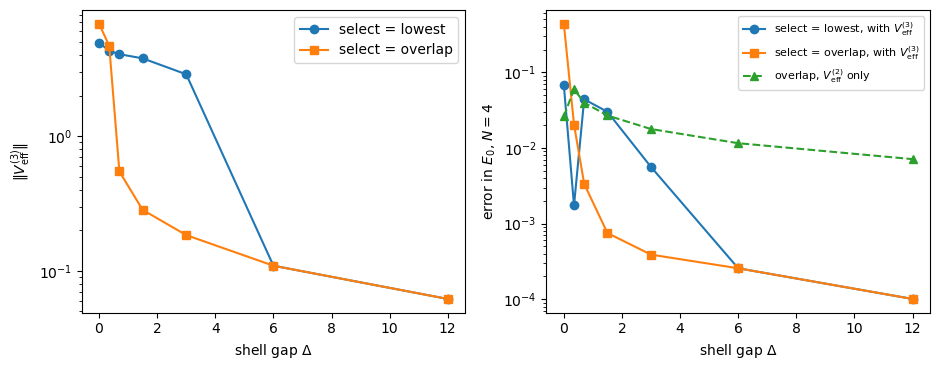

In [12]:
gaps = [0.0, 0.35, 0.7, 1.5, 3.0, 6.0, 12.0]
rows = {"lowest": [], "overlap": []}
for g in gaps:
    hg = ho.one_body(gap=g, n_P=n_P)
    for sel in rows:
        chg = e3.ClusterHierarchy(hg, v_default, n_P, orbital_parity=ho.parity(), select=sel)
        s4 = chg.model_space_spectra(4, n_states=1)
        rows[sel].append((max(chg.ls[3].condition_numbers.values()),
                          chg.V3_eff.norm(),
                          abs(s4["h + V2_eff + V3_eff"][0] - s4["exact"][0]),
                          abs(s4["h + V2_eff"][0] - s4["exact"][0])))
print(f"{'gap':>5s} | {'cond(PK), lowest':>17s} {'||V3||':>8s} {'N=4 err':>9s} | "
      f"{'cond(PK), overlap':>18s} {'||V3||':>8s} {'N=4 err':>9s}")
for g, a, b in zip(gaps, rows["lowest"], rows["overlap"]):
    print(f"{g:5.2f} | {a[0]:17.1f} {a[1]:8.3f} {a[2]:9.2e} | {b[0]:18.1f} {b[1]:8.3f} {b[2]:9.2e}")

fig, ax = plt.subplots(1, 2, figsize=(9.5, 3.8))
for sel, mk in (("lowest", "o-"), ("overlap", "s-")):
    r = np.array(rows[sel])
    ax[0].semilogy(gaps, r[:, 1], mk, label=f"select = {sel}")
    ax[1].semilogy(gaps, r[:, 2], mk, label=f"select = {sel}, with $V^{{(3)}}_{{\\rm eff}}$")
ax[1].semilogy(gaps, np.array(rows["overlap"])[:, 3], "^--", label=r"overlap, $V^{(2)}_{\rm eff}$ only")
ax[0].set_xlabel(r"shell gap $\Delta$"); ax[0].set_ylabel(r"$\|V^{(3)}_{\rm eff}\|$"); ax[0].legend()
ax[1].set_xlabel(r"shell gap $\Delta$"); ax[1].set_ylabel(r"error in $E_0$, $N=4$"); ax[1].legend(fontsize=8)
plt.tight_layout(); plt.show()

For a large gap the two selection rules coincide and the hierarchy converges.
Below $\Delta\approx5$, the point where the highest model-space
determinants start to overlap in energy with the lowest excluded ones, the
"lowest" rule picks up intruders and $V^{(3)}_{\rm eff}$ becomes as large as
$V^{(2)}_{\rm eff}$; the four-particle energy obtained with it improves
erratically and for small gaps is *worse* than with $V^{(2)}_{\rm eff}$
alone.  The overlap rule survives down to
$\Delta\approx0.7$, but at $\Delta=0$, the pure oscillator with orbital
truncation, it fails as well.  This is the intruder-state problem in its
simplest incarnation and the reason why realistic calculations either
truncate on total excitation energy (no-core shell model), or soften the
interaction first so that the decoupling is mild (SRG, $V_{{\rm low}\,k}$),
or both.

## 11. Summary and tasks

Exact eigenpairs of the $a$-particle problem -- full configuration
interaction in the large space -- define, through the Lee-Suzuki-Okubo
transformation, an effective Hamiltonian in the $a$-particle model space
that reproduces $d_P$ exact eigenvalues.  Because a $k$-body operator is
fixed by its $k$-particle matrix elements, the $a$-particle effective
Hamiltonians can be peeled apart cluster by cluster: the two-particle problem
gives $V^{(2)}_{\rm eff}$, the three-particle problem gives the induced
$V^{(3)}_{\rm eff}$, and so on.  Applied to an $N$-particle system in the
small space -- full configuration interaction again, now affordable -- the
truncated hierarchy converges quickly when the model space is well separated
from its complement and the interaction is not too strong, and it breaks
down, through intruder states, when it is not.  The induced three-body force
is not an artefact to be removed but the price of working in a small space;
it is of second order in the interaction and it is the same object that
appears when a nuclear Hamiltonian is softened by the similarity
renormalisation group.

**Tasks** (the full formulation is in Appendix A of the book; tasks a) to d)
have reference solutions in this notebook, e) to g) are open)

- a) *Embedding and the Condon-Slater rules.*  Implement the embedding
  formula of section 3 on top of the bit-string routines of `fci.py`, verify
  it for $k=1,2$ against the Condon-Slater rules, and display the band
  structure of the three-particle Hamiltonian with respect to $|012\rangle$
  with and without $V^{(3)}_{\rm eff}$ (exercise 2b of chapter 5).
- b) *The Lee-Suzuki-Okubo transformation.*  Construct $H_{\rm eff}$ for
  two particles in each parity sector, check Hermiticity and the spectrum,
  then solve the quadratic equation for $\omega$ by the iteration
  $\omega_{n+1}=(QHQ)^{-1}(\omega_nPHP+\omega_nPHQ\omega_n-QHP)$ from
  $\omega_0=0$ and find out which solution it selects, and when it fails.
- c) *The cluster hierarchy.*  Extract $V^{(2)}_{\rm eff}$,
  $V^{(3)}_{\rm eff}$ and $V^{(4)}_{\rm eff}$, reproduce the spectra of
  sections 6 and 7, and verify that all of them vanish when $n_P=n$.
- d) *Scaling and intruders.*  Reproduce sections 8 to 10, fit the
  weak-coupling exponent, list the degenerate $P$ and $Q$ determinants of
  the pure oscillator, and propose a third selection rule.
- e) *Open: normal ordering.*  Normal order $V^{(3)}_{\rm eff}$ with respect
  to $|0123\rangle$ (chapter 3), keep the zero-, one- and two-body parts,
  and measure how much of the four-particle three-body effect the
  normal-ordered two-body approximation captures; then feed the
  normal-ordered Hamiltonian to the coupled-cluster code of chapter 10.
- f) *Open: second-order perturbation theory.*  Compute
  $P\hat HP+P\hat VQ(E_0-\hat H_0)^{-1}Q\hat VP$ for three particles
  (chapter 9), isolate the connected three-body terms, and compare with
  $V^{(3)}_{\rm eff}$ at $V_0=-0.25$ and $V_0=-2$.
- g) *Open: the similarity renormalisation group.*  Evolve the Hamiltonian
  with $dH_s/ds=[[T,H_s],H_s]$ in the two- and three-particle spaces,
  extract the induced three-body term, combine softening with the
  model-space decoupling, and replace the orbital truncation by the
  $N_{\max}$ truncation of the no-core shell model (Navrátil and Ormand,
  Phys. Rev. C **68**, 034305 (2003)).